In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve
import joblib
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv("wildfire_train_split.csv")
test_df = pd.read_csv("wildfire_test_split.csv")

In [3]:
feature_cols = [
    'cluster_id',
    'pr', 'rmax', 'rmin', 'sph', 'srad', 'tmmn', 'tmmx', 'vs',
    'vpd', 'fm100', 'fm1000', 'erc', 'bi', 'etr', 'pet'
]

In [4]:
X_train = train_df[feature_cols]
y_train = train_df['Wildfire_binary']
X_test = test_df[feature_cols]
y_test = test_df['Wildfire_binary']

In [5]:
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=200,
    min_samples_leaf=50,
    subsample=0.8,
    max_features='sqrt',
    random_state=42,
    verbose=1
)

In [6]:
gbm.fit(X_train, y_train)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.3386           0.0010           21.27m
         2           0.3383           0.0028           22.18m
         3           0.3374           0.0004           21.53m
         4           0.3360          -0.0018           21.19m
         5           0.3358           0.0026           21.15m
         6           0.3356           0.0023           21.02m
         7           0.3350          -0.0000           20.72m
         8           0.3347           0.0000           20.58m
         9           0.3344           0.0004           20.37m
        10           0.3341           0.0005           20.20m
        20           0.3318          -0.0002           18.20m
        30           0.3311           0.0015           15.83m
        40           0.3300          -0.0011           13.35m
        50           0.3297           0.0012           11.03m
        60           0.3295          -0.0017            8.80m
       

GradientBoostingClassifier(max_depth=4, max_features='sqrt',
                           min_samples_leaf=50, min_samples_split=200,
                           random_state=42, subsample=0.8, verbose=1)

In [7]:
y_pred = gbm.predict(X_test)
y_pred_proba = gbm.predict_proba(X_test)[:, 1]

In [8]:
accuracy = accuracy_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)
baseline_accuracy = (y_test == 0).mean()

In [9]:
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"Baseline (always predict no fire): {baseline_accuracy:.4f}")
print(f"Improvement: {((accuracy - baseline_accuracy) / baseline_accuracy * 100):+.1f}%")

Accuracy: 0.8796
AUC-ROC: 0.5939
Baseline (always predict no fire): 0.8796
Improvement: +0.0%


In [10]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gbm.feature_importances_
}).sort_values('importance', ascending=False)
for i, row in feature_importance.iterrows():
    print(f"{i+1:2d}. {row['feature']:15} {row['importance']:.4f}")

12. fm1000          0.2689
 1. cluster_id      0.1274
13. erc             0.1244
 6. srad            0.1080
 4. rmin            0.0572
14. bi              0.0530
11. fm100           0.0510
 5. sph             0.0424
 7. tmmn            0.0347
 8. tmmx            0.0305
16. pet             0.0292
 9. vs              0.0196
15. etr             0.0177
10. vpd             0.0165
 3. rmax            0.0125
 2. pr              0.0070


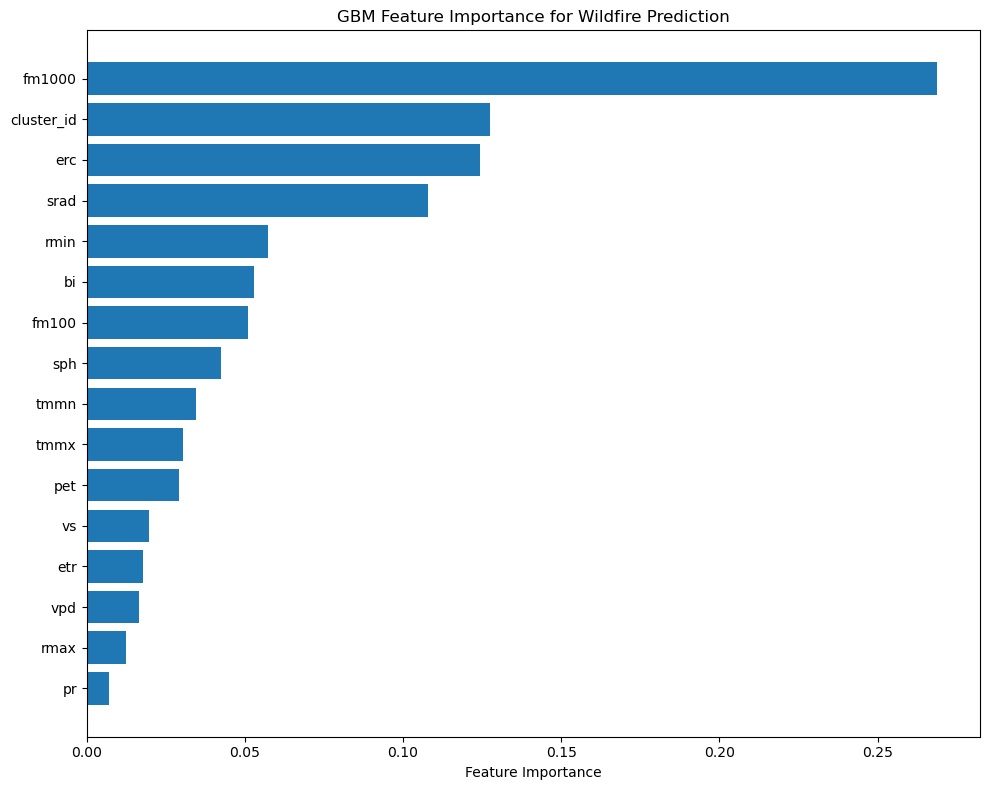

In [11]:
plt.figure(figsize=(10, 8))
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gbm.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance')
plt.title('GBM Feature Importance for Wildfire Prediction')
plt.tight_layout()
plt.show()

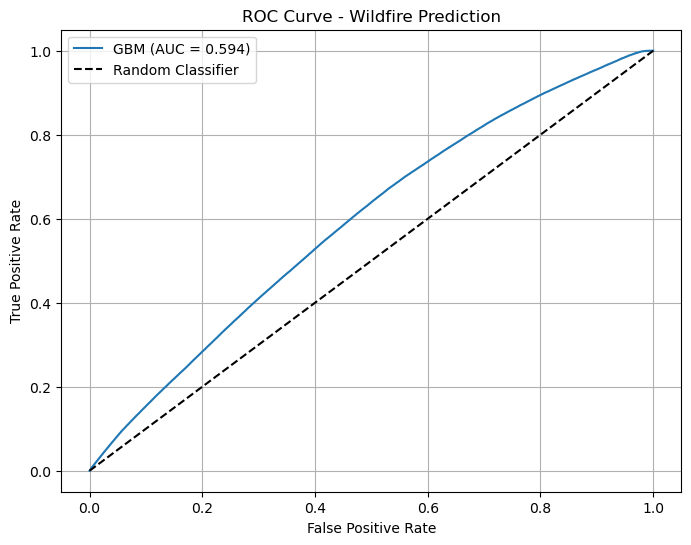

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'GBM (AUC = {auc_roc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Wildfire Prediction')
plt.legend()
plt.grid(True)
plt.show()